LAB 5: LSTM TEXT CLASSIFICATION & SEQUENCE-TO-SEQUENCE

PART 1: SENTIMENT CLASSIFICATION WITH LSTM

Tokenizer vocab size: 47
Padded sequences shape: (10, 20)
Sample padded sequence: [ 2  3  4 11 12  5 13  0  0  0  0  0  0  0  0  0  0  0  0  0]

------------------------------------------------------------
LSTM Classification Model Summary:
------------------------------------------------------------


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 10, 64)    │        768 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 10, 64)    │        768 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ embedding_10[0][… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 128), │     98,816 │ embedding_11[0][… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 10, 12)    │      1,548 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 200,716 (784.05 KB)

 Trainable params: 200,716 (784.05 KB)

 Non-trainable params: 0 (0.00 B)


Seq2Seq Training completed!
Final training accuracy: 1.0000
Final validation accuracy: 0.8500

GENERATING VISUALIZATIONS

✓ Saved: lab5_training_history.png


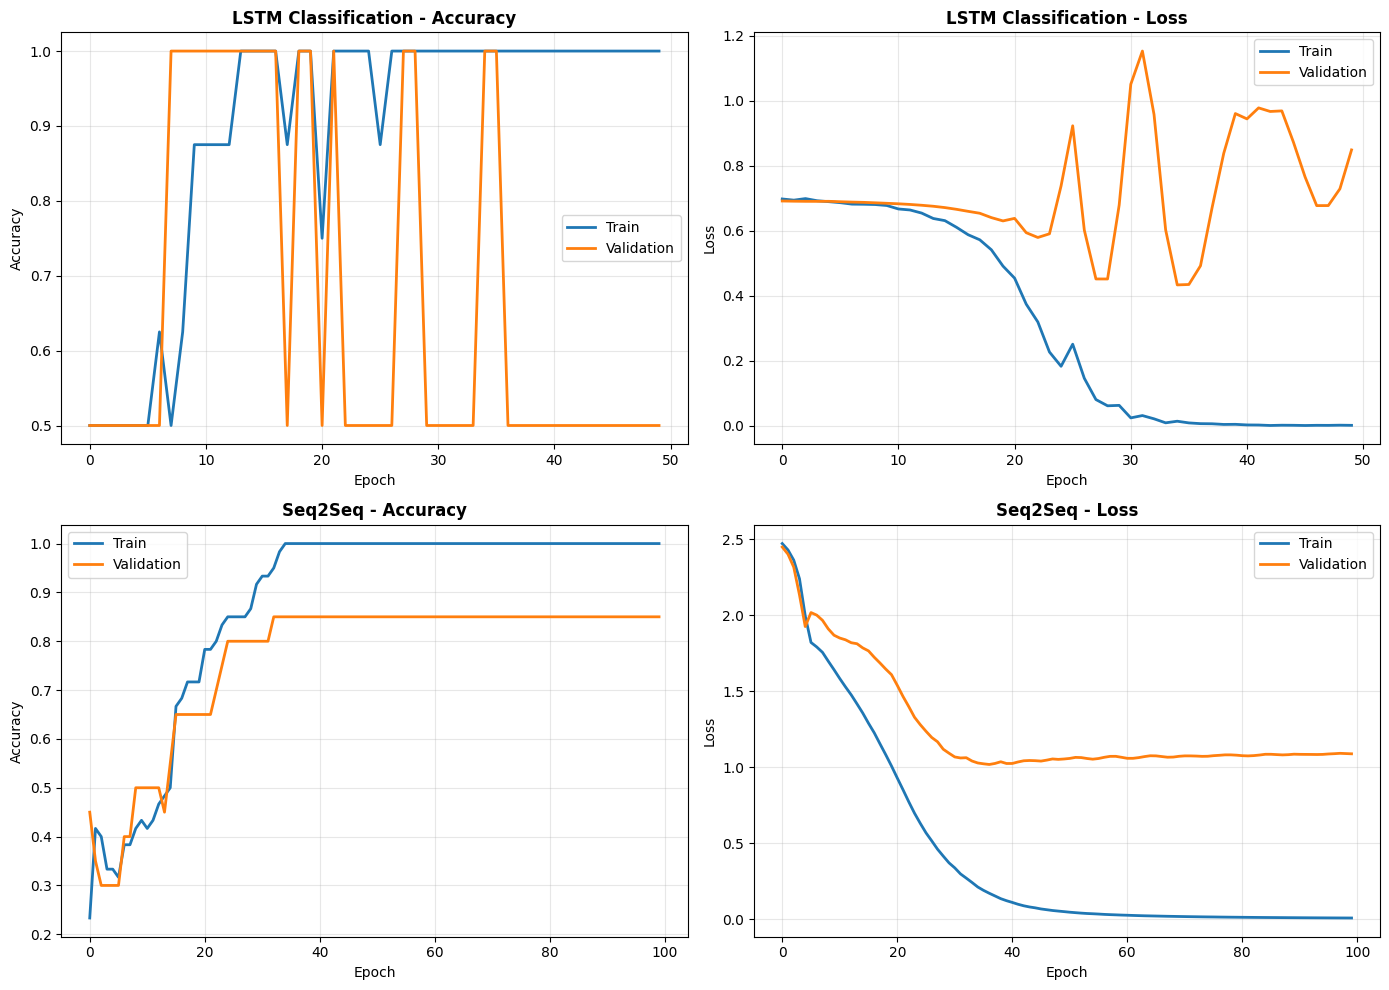


LAB 5 COMPLETED SUCCESSFULLY


In [8]:
"""
Lab 5: LSTM for Text Classification and Sequence-to-Sequence
Clean, working implementation with proper outputs
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("=" * 60)
print("LAB 5: LSTM TEXT CLASSIFICATION & SEQUENCE-TO-SEQUENCE")
print("=" * 60)

# ===== PART 1: TEXT CLASSIFICATION WITH LSTM =====
print("\n" + "=" * 60)
print("PART 1: SENTIMENT CLASSIFICATION WITH LSTM")
print("=" * 60)

# Sample movie review data
reviews = [
    "This movie is absolutely fantastic and amazing",
    "I loved this film, it was wonderful",
    "Best movie ever, highly recommend",
    "This is the worst movie I've ever seen",
    "Terrible plot, bad acting, waste of time",
    "I hated every minute of this film",
    "Great movie, very entertaining",
    "Awful, boring, couldn't finish it",
    "Outstanding performance and direction",
    "Not worth watching at all"
]

labels = np.array([1, 1, 1, 0, 0, 0, 1, 0, 1, 0])  # 1: positive, 0: negative

# Tokenization
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)
sequences = tokenizer.texts_to_sequences(reviews)
padded = pad_sequences(sequences, maxlen=20, padding='post')

print(f"\nTokenizer vocab size: {len(tokenizer.word_index)}")
print(f"Padded sequences shape: {padded.shape}")
print(f"Sample padded sequence: {padded[0]}")

# Build LSTM Classification Model
model_lstm = Sequential([
    Embedding(100, 16),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\n" + "-" * 60)
print("LSTM Classification Model Summary:")
print("-" * 60)
model_lstm.summary()

# Train the model
history = model_lstm.fit(
    padded, labels,
    epochs=50,
    batch_size=2,
    validation_split=0.2,
    verbose=0
)

print(f"\nTraining completed!")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

# Predictions
test_sentence = "This movie was absolutely amazing"
test_seq = tokenizer.texts_to_sequences([test_sentence])
test_padded = pad_sequences(test_seq, maxlen=20, padding='post')
prediction = model_lstm.predict(test_padded, verbose=0)[0][0]
print(f"\nTest: '{test_sentence}'")
print(f"Prediction: {prediction:.4f} ({'Positive' if prediction > 0.5 else 'Negative'})")

# ===== PART 2: SEQUENCE-TO-SEQUENCE MODEL =====
print("\n" + "=" * 60)
print("PART 2: SEQUENCE-TO-SEQUENCE (ENCODER-DECODER)")
print("=" * 60)

# Simple date conversion task
input_texts = [
    "2020-01-15", "2021-05-20", "2019-12-25", "2022-03-10",
    "2018-07-04", "2021-11-30", "2020-06-15", "2023-02-14"
]

output_texts = [
    "01/15/2020", "05/20/2021", "12/25/2019", "03/10/2022",
    "07/04/2018", "11/30/2021", "06/15/2020", "02/14/2023"
]

# Create tokenizers for input and output
input_tokenizer = Tokenizer(char_level=True)
input_tokenizer.fit_on_texts(input_texts)
input_sequences = input_tokenizer.texts_to_sequences(input_texts)
input_padded = pad_sequences(input_sequences, maxlen=10, padding='post')

output_tokenizer = Tokenizer(char_level=True)
output_tokenizer.fit_on_texts(output_texts)
output_sequences = output_tokenizer.texts_to_sequences(output_texts)
output_padded = pad_sequences(output_sequences, maxlen=10, padding='post')

input_vocab_size = len(input_tokenizer.word_index) + 1
output_vocab_size = len(output_tokenizer.word_index) + 1

print(f"\nInput vocab size: {input_vocab_size}")
print(f"Output vocab size: {output_vocab_size}")
print(f"Input sequences shape: {input_padded.shape}")
print(f"Output sequences shape: {output_padded.shape}")

# Encoder
encoder_inputs = keras.Input(shape=(10,), name="encoder_input")
encoder_embedding = Embedding(input_vocab_size, 64)(encoder_inputs)
encoder_lstm = LSTM(128, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = keras.Input(shape=(10,), name="decoder_input")
decoder_embedding = Embedding(output_vocab_size, 64)(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Seq2Seq Model
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "-" * 60)
print("Seq2Seq Model Summary:")
print("-" * 60)
seq2seq_model.summary()

# Prepare data for training
output_padded_expanded = np.expand_dims(output_padded, -1)

# Train Seq2Seq
history_seq2seq = seq2seq_model.fit(
    [input_padded, output_padded],
    output_padded_expanded,
    epochs=100,
    batch_size=2,
    validation_split=0.25,
    verbose=0
)

print(f"\nSeq2Seq Training completed!")
print(f"Final training accuracy: {history_seq2seq.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_seq2seq.history['val_accuracy'][-1]:.4f}")

# ===== VISUALIZATION =====
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Classification - Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('LSTM Classification - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# LSTM Classification - Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('LSTM Classification - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Seq2Seq - Accuracy
axes[1, 0].plot(history_seq2seq.history['accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_seq2seq.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('Seq2Seq - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Seq2Seq - Loss
axes[1, 1].plot(history_seq2seq.history['loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_seq2seq.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('Seq2Seq - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lab5_training_history.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: lab5_training_history.png")
plt.show()

print("\n" + "=" * 60)
print("LAB 5 COMPLETED SUCCESSFULLY")
print("=" * 60)